# Stage 4 - Shape the forecast position Day-Ahead

**Input:** the hedge energy per strategy (`data/hedge_energy.csv`), the futures positions
(`data/hedge_positions.csv`) with the products they were sized from
(`data/selected_products.csv`) and the HPFC's block/Peak grid (`data/hpfc.csv`), and the realised
Day-Ahead price (`data/day_ahead_prices.csv`)

**Output:** the per-quarter-hour Day-Ahead residual for every strategy (`data/residual_da.csv`)
and the resulting forecast-position cost (`data/forecast_costs.csv`)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

DATA = "../data"
DT = 0.25   # quarter-hour, in hours
C_CAL, C_GRAN, C_UNHEDGED = "#DD8452", "#4C72B0", "#8172B3"   # COARSE_CAL, GRANULAR, UNHEDGED

energy    = pd.read_csv(f"{DATA}/hedge_energy.csv")
positions = pd.read_csv(f"{DATA}/hedge_positions.csv")
selected  = pd.read_csv(f"{DATA}/selected_products.csv")
hpfc      = pd.read_csv(f"{DATA}/hpfc.csv")
day_ahead = pd.read_csv(f"{DATA}/day_ahead_prices.csv")

df = energy.merge(day_ahead[["timestamp_utc", "day_ahead_price_eur_mwh"]], on="timestamp_utc", validate="one_to_one")
df["t_local"] = pd.to_datetime(df["timestamp_utc"], utc=True).dt.tz_convert("Europe/Berlin")
assert df.isna().sum().sum() == 0

STRATEGIES = {"UNHEDGED": "hedge_unhedged_mwh", "COARSE_CAL": "hedge_coarse_cal_mwh", "GRANULAR": "hedge_granular_mwh"}
COLORS = {"UNHEDGED": C_UNHEDGED, "COARSE_CAL": C_CAL, "GRANULAR": C_GRAN}

print("merged grid:", df.shape, "-> hedge energy (Stage 3) x realised Day-Ahead price")
df.head()

merged grid: (35136, 7) -> hedge energy (Stage 3) x realised Day-Ahead price


,timestamp_utc,load_mwh,hedge_coarse_cal_mwh,hedge_granular_mwh,hedge_unhedged_mwh,day_ahead_price_eur_mwh,t_local
0,2023-12-31T23:00:00Z,1.08,1.10,1.26,0.00,0.10,2024-01-01 00:00:00+01:00
1,2023-12-31T23:15:00Z,1.00,1.10,1.26,0.00,0.10,2024-01-01 00:15:00+01:00
2,2023-12-31T23:30:00Z,0.93,1.10,1.26,0.00,0.10,2024-01-01 00:30:00+01:00
3,2023-12-31T23:45:00Z,0.87,1.10,1.26,0.00,0.10,2024-01-01 00:45:00+01:00
4,2024-01-01T00:00:00Z,0.80,1.10,1.26,0.00,0.01,2024-01-01 01:00:00+01:00


## 1. The Day-Ahead residual $R_t^{DA}$

The futures are financial contracts; they never change the physical schedule. Whatever the hedge
does not cover in a given quarter-hour, the company must still buy (or can sell) in the Day-Ahead
market to deliver the forecast load $L_t$ exactly:

$$R_t^{DA} = L_t - H_t$$

$H_t$ is the strategy's hedge energy from Stage 3 (`hedge_*_mwh` in `hedge_energy.csv`). For
`UNHEDGED`, $H_t \equiv 0$, so $R_t^{DA} \equiv L_t$: the complete forecast load remains exposed to
the Day-Ahead price, exactly as required.

In [2]:
for strategy, col in STRATEGIES.items():
    df[f"R_DA_{strategy}"] = df["load_mwh"] - df[col]

assert np.allclose(df["R_DA_UNHEDGED"], df["load_mwh"]), "UNHEDGED must leave the full forecast load exposed"

annual_residual = pd.DataFrame({
    "hedge_notional_MWh":    {s: df[c].sum() for s, c in STRATEGIES.items()},
    "residual_DA_net_MWh":   {s: df[f"R_DA_{s}"].sum() for s in STRATEGIES},
    "residual_DA_abs_MWh":   {s: df[f"R_DA_{s}"].abs().sum() for s in STRATEGIES},
}).reindex(["UNHEDGED", "COARSE_CAL", "GRANULAR"])
annual_residual["load_MWh"] = df["load_mwh"].sum()
annual_residual

,hedge_notional_MWh,residual_DA_net_MWh,residual_DA_abs_MWh,load_MWh
UNHEDGED,0.00,"43,000.00","43,000.00","43,000.00"
COARSE_CAL,"44,503.82","-1,503.82","12,760.13","43,000.00"
GRANULAR,"44,079.18","-1,079.18","11,985.15","43,000.00"


**Reading the table.** `residual_DA_net_MWh` is small for the two optimized strategies (a few
hundred MWh, positive or negative depending on how the year's realised prices happen to sit against
the block-level hedge) - value neutrality does not target zero net residual, only zero net
*value*. `residual_DA_abs_MWh` is the Stage 3 "absolute residual Day-Ahead volume" measure: the
total energy that actually has to be bought or sold quarter-hour by quarter-hour, regardless of
sign - close to the full 43,000 MWh forecast load for `UNHEDGED`, and roughly 28% of it for the two
hedged strategies.

## 2. Cost of the forecast position

**Fixed futures cost.** A futures position is agreed today at a fixed price and does not depend on
what the Day-Ahead price later turns out to be. Within block $b$, a Base position of $x_{base,b}$ MW
pays $P_{base,b}$ on *every* interval of the block ($N_{all,b}$ of them); a Peak position of
$x_{peak,b}$ MW pays $P_{peak,b}$ only on the block's Peak intervals ($N_{peak,b}$ of them):

$$C_{futures} = \Delta t \sum_b \Big( x_{base,b} \cdot N_{all,b} \cdot P_{base,b} \;+\; x_{peak,b} \cdot N_{peak,b} \cdot P_{peak,b} \Big)$$

`COARSE_CAL` has one block (`CAL`, the whole year); `GRANULAR` has the six Stage 2/3 blocks (M01,
M02, M03, Q2, Q3, Q4). `UNHEDGED` holds no futures, so $C_{futures} = 0$.

**Cost of the forecast position.** Add the Day-Ahead cost (or revenue) of the residual, priced at
the *realised* Day-Ahead price $P_t^{DA}$:

$$C_{residual}^{DA} = \sum_t R_t^{DA} \cdot P_t^{DA} \qquad\qquad C_{forecast} = C_{futures} + C_{residual}^{DA}$$

In [3]:
# N_all / N_peak per block, incl. the single COARSE_CAL block "CAL" spanning the full year
counts = hpfc.groupby("period")["is_peak"].agg(N_all="size", N_peak="sum")
counts.loc["CAL"] = [len(hpfc), hpfc["is_peak"].sum()]

price_base = selected[selected["load_type"] == "BASE"].set_index("delivery_period")["price_eur_mwh"]
price_peak = selected[selected["load_type"] == "PEAK"].set_index("delivery_period")["price_eur_mwh"]

pos = positions[positions["strategy"] != "UNHEDGED"].copy()
pos["N_all"]  = pos["block"].map(counts["N_all"])
pos["N_peak"] = pos["block"].map(counts["N_peak"])
pos["P_base"] = pos["block"].map(price_base)
pos["P_peak"] = pos["block"].map(price_peak)
pos["C_futures_block"] = DT * (pos["x_base_MW"] * pos["N_all"] * pos["P_base"]
                                + pos["x_peak_MW"] * pos["N_peak"] * pos["P_peak"])

C_futures = pos.groupby("strategy")["C_futures_block"].sum().reindex(["UNHEDGED", "COARSE_CAL", "GRANULAR"]).fillna(0.0)
pos[["strategy", "block", "x_base_MW", "x_peak_MW", "N_all", "N_peak", "P_base", "P_peak", "C_futures_block"]]

,strategy,block,x_base_MW,x_peak_MW,N_all,N_peak,P_base,P_peak,C_futures_block
0,COARSE_CAL,CAL,4.39,1.88,35136,12576,77.26,86.60,"3,493,701.73"
1,GRANULAR,M01,5.04,2.33,2976,1104,75.32,88.68,"339,688.94"
2,GRANULAR,M02,4.93,2.22,2784,1008,60.09,70.59,"245,756.49"
3,GRANULAR,M03,4.65,1.97,2972,1008,63.45,72.79,"255,419.47"
4,GRANULAR,Q2,4.00,1.68,8736,3120,66.23,64.76,"663,355.19"
5,GRANULAR,Q3,3.85,1.54,8832,3168,74.74,69.07,"719,370.73"
6,GRANULAR,Q4,4.66,2.13,8836,3168,101.39,134.42,"1,270,115.09"


In [4]:
C_residual_DA = pd.Series({s: (df[f"R_DA_{s}"] * df["day_ahead_price_eur_mwh"]).sum() for s in STRATEGIES})
C_forecast = C_futures + C_residual_DA

forecast_cost = pd.DataFrame({
    "C_futures_EUR": C_futures,
    "C_residual_DA_EUR": C_residual_DA,
    "C_forecast_EUR": C_forecast,
}).reindex(["UNHEDGED", "COARSE_CAL", "GRANULAR"])
forecast_cost

,C_futures_EUR,C_residual_DA_EUR,C_forecast_EUR
UNHEDGED,0.00,"3,506,703.99","3,506,703.99"
COARSE_CAL,"3,493,701.73","-42,735.09","3,450,966.64"
GRANULAR,"3,493,705.92","-42,198.57","3,451,507.34"


## 3. Validate through the equivalent financial representation

A futures position can equally be read as a swap: pay the fixed $C_{futures}$ agreed today, receive
the floating value the hedge energy would fetch at the realised Day-Ahead price. That receipt minus
the fixed payment is the financial futures payoff:

$$\Pi_{futures} = \sum_t H_t \cdot P_t^{DA} \;-\; C_{futures}$$

Substituting $R_t^{DA} = L_t - H_t$ into $C_{forecast}$ and rearranging with this definition gives
the identity the assignment asks us to check:

$$C_{forecast} = C_{futures} + \sum_t (L_t - H_t) P_t^{DA} = \sum_t L_t P_t^{DA} - \Big(\sum_t H_t P_t^{DA} - C_{futures}\Big) = \sum_t L_t \cdot P_t^{DA} - \Pi_{futures}$$

This must hold exactly (up to floating-point rounding) for every strategy, including `UNHEDGED`
where $H_t \equiv 0$ and $C_{futures} = 0$, so $\Pi_{futures} = 0$ and $C_{forecast}$ collapses to
the full forecast load priced at the Day-Ahead price - no futures value to net out.

In [5]:
Pi_futures = pd.Series({s: (df[STRATEGIES[s]] * df["day_ahead_price_eur_mwh"]).sum() - C_futures[s] for s in STRATEGIES})
load_value_DA = (df["load_mwh"] * df["day_ahead_price_eur_mwh"]).sum()
C_forecast_check = load_value_DA - Pi_futures

reconciliation = pd.DataFrame({
    "C_forecast_EUR (physical)": C_forecast,
    "C_forecast_EUR (financial check)": C_forecast_check,
    "difference_EUR": C_forecast - C_forecast_check,
}).reindex(["UNHEDGED", "COARSE_CAL", "GRANULAR"])

assert np.allclose(C_forecast, C_forecast_check, atol=1e-6), "the two cost representations must reconcile exactly"
assert Pi_futures["UNHEDGED"] == 0.0 and C_futures["UNHEDGED"] == 0.0
print("Reconciled: both representations of C_forecast agree to the cent for every strategy.")
reconciliation

Reconciled: both representations of C_forecast agree to the cent for every strategy.


,C_forecast_EUR (physical),C_forecast_EUR (financial check),difference_EUR
UNHEDGED,"3,506,703.99","3,506,703.99",0.00
COARSE_CAL,"3,450,966.64","3,450,966.64",0.00
GRANULAR,"3,451,507.34","3,451,507.34",-0.00


**Interpreting `day_ahead_residual` ($R_t^{DA}$).**

- **Positive** ($L_t > H_t$): the hedge under-covers the forecast load in that quarter-hour. The
  company must **buy** the shortfall in the Day-Ahead market at $P_t^{DA}$ - a cost.
- **Negative** ($L_t < H_t$): the hedge over-covers the forecast load. The physical schedule only
  needs $L_t$, so the surplus futures energy must be **sold back** into the Day-Ahead market at
  $P_t^{DA}$ - a credit that reduces $C_{residual}^{DA}$ (and can make it negative overall, as seen
  above for both `COARSE_CAL` and `GRANULAR`: their hedges run value-neutral but volume-*long* on
  average, per Stage 3, so the net Day-Ahead action across the year is a small net sale).

Either way the sign is an instruction, not a problem: Day-Ahead shaping is exactly the mechanism
that reconciles a block-level financial hedge with a quarter-hourly physical schedule. `UNHEDGED`
is the boundary case where every single interval is positive and must be bought in full.

## 4. Visualize the Day-Ahead residual

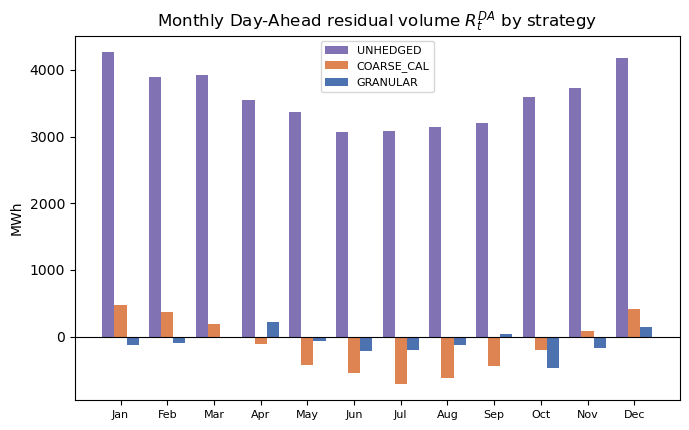

In [6]:
monthly_residual = df.set_index("t_local")[[f"R_DA_{s}" for s in STRATEGIES]].resample("MS").sum()
monthly_residual.columns = list(STRATEGIES.keys())

fig, ax = plt.subplots(figsize=(7, 4.4))
x = np.arange(12); width = 0.26
for i, strategy in enumerate(STRATEGIES):
    ax.bar(x + (i - 1) * width, monthly_residual[strategy], width, color=COLORS[strategy], label=strategy)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels([d.strftime("%b") for d in monthly_residual.index], fontsize=8)
ax.set_ylabel("MWh"); ax.set_title(r"Monthly Day-Ahead residual volume $R_t^{DA}$ by strategy")
ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

**Comment.** `UNHEDGED` must buy the entire load every month (always positive, 3,000-4,300
MWh), while `COARSE_CAL` and `GRANULAR` swing close to zero and flip sign seasonally - selling
surplus hedge energy back in the shoulder months (Apr-Sep, when the flat Base/Peak hedge
over-covers a lower load) and buying a top-up in winter (when the hedge under-covers the higher
load), consistent with Stage 3's Q4 Peak-heavy positions.

## 5. Save the Day-Ahead result

In [7]:
residual_cols = ["timestamp_utc", "load_mwh"] + list(STRATEGIES.values()) + [f"R_DA_{s}" for s in STRATEGIES] + ["day_ahead_price_eur_mwh"]
residual_da = df[residual_cols]
residual_da.to_csv(f"{DATA}/residual_da.csv", index=False)

forecast_costs = forecast_cost.copy()
forecast_costs["Pi_futures_EUR"] = Pi_futures
forecast_costs_out = forecast_costs.rename_axis("strategy").reset_index()
forecast_costs_out.to_csv(f"{DATA}/forecast_costs.csv", index=False)

print("saved:", f"{DATA}/residual_da.csv", residual_da.shape)
print("saved:", f"{DATA}/forecast_costs.csv", forecast_costs_out.shape)
forecast_costs_out

saved: ../data/residual_da.csv (35136, 9)
saved: ../data/forecast_costs.csv (3, 5)


,strategy,C_futures_EUR,C_residual_DA_EUR,C_forecast_EUR,Pi_futures_EUR
0,UNHEDGED,0.00,"3,506,703.99","3,506,703.99",0.00
1,COARSE_CAL,"3,493,701.73","-42,735.09","3,450,966.64","55,737.35"
2,GRANULAR,"3,493,705.92","-42,198.57","3,451,507.34","55,196.65"
